In [1]:
import pandas as pd
import seaborn as sns

In [3]:
dataset = pd.read_excel(r'/content/Admission_St.xlsx')

In [4]:
dataset

,Admit,GRE,GPA,RANK
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4
...,...,...,...,...
395,0,620,4.00,2
396,0,560,3.04,3
397,0,460,2.63,2
398,0,700,3.65,2


In [5]:
X = dataset.iloc[:, 1:4]

In [6]:
y = dataset.iloc[:, 0]

In [7]:
y.value_counts()

,count
Admit,
0,273
1,127


<Axes: xlabel='Admit', ylabel='count'>

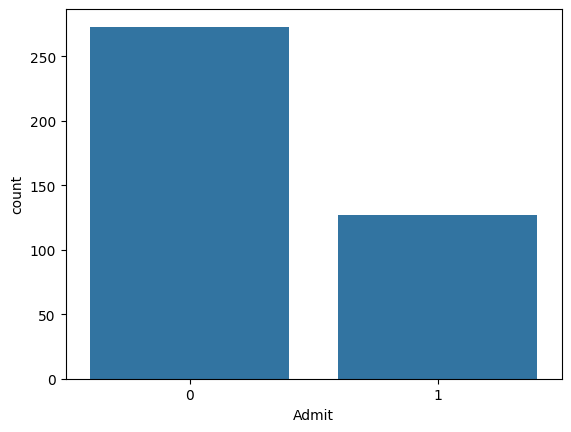

In [8]:
sns.countplot(x="Admit", data=dataset)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [12]:
len(X_train)
len(y_train)

280

In [11]:
len(X_test)
len(y_test)

120

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [18]:
acc1 = accuracy_score(y_test, y_pred)
prec1 = precision_score(y_test, y_pred)
rec1 = recall_score(y_test, y_pred)
f11 = f1_score(y_test, y_pred)
print("Before SMOTE")
print("Accuracy: ", acc1)
print("Precision: ", prec1)
print("Recall: ", rec1)
print("F1 Score: ", f11)
print(classification_report(y_test, y_pred))

Before SMOTE
Accuracy:  0.7333333333333333
Precision:  0.7142857142857143
Recall:  0.2631578947368421
F1 Score:  0.38461538461538464
              precision    recall  f1-score   support

           0       0.74      0.95      0.83        82
           1       0.71      0.26      0.38        38

    accuracy                           0.73       120
   macro avg       0.73      0.61      0.61       120
weighted avg       0.73      0.73      0.69       120



In [19]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [20]:
len(y_ros)

382

In [22]:
y_ros.value_counts()

,count
Admit,
0,191
1,191


In [23]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_train, y_train)

In [24]:
len(y_rus)

178

In [25]:
y_rus.value_counts()

,count
Admit,
0,89
1,89


In [26]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(k_neighbors=3)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
y_smote.value_counts()

,count
Admit,
0,191
1,191


In [30]:
from sklearn.linear_model import LogisticRegression
log_model_smote = LogisticRegression(max_iter=5000)
log_model_smote.fit(X_smote, y_smote)

LogisticRegression(max_iter=5000)

In [31]:
y_pred_smote = log_model_smote.predict(X_test)
y_prob_smote = log_model_smote.predict_proba(X_test)[:,1]

In [35]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
acc1 = accuracy_score(y_test, y_pred_smote)
prec1 = precision_score(y_test, y_pred_smote)
rec1 = recall_score(y_test, y_pred_smote)
f11 = f1_score(y_test, y_pred_smote)
print("Before SMOTE")
print("Accuracy: ", acc1)
print("Precision: ", prec1)
print("Recall: ", rec1)
print("F1 Score: ", f11)
print(classification_report(y_test, y_pred_smote))

Before SMOTE
Accuracy:  0.65
Precision:  0.46153846153846156
Recall:  0.631578947368421
F1 Score:  0.5333333333333333
              precision    recall  f1-score   support

           0       0.79      0.66      0.72        82
           1       0.46      0.63      0.53        38

    accuracy                           0.65       120
   macro avg       0.63      0.65      0.63       120
weighted avg       0.69      0.65      0.66       120



After applying smote the accuracy and precision has decreased and he value of f1 score and rcall has increaed